# Data Science & AI/ML · Practical Exam · **Set C**
**Student name:** KRISHA ANGHAN  |  **Student ID:** 10771  |  **Set:** C

**Problem:** predict late deliveries (`late` = 1) and identify operational segments, using a synthetic dataset.
All data are synthetic practice observations — no causal claims and no deployment-readiness claims are made.

Sections: **0 Setup & data** · **1 Maths & Adv Stats** · **2 Preprocessing & Feature Engineering** ·
**3 Supervised Learning** · **4 Unsupervised Learning** · **5 Deep Learning (ANN)** · **6 Reconciliation & evidence**


In [1]:
import os, sys, json, subprocess, platform, random
from pathlib import Path

# --- move to repository root (works whether launched from root or notebooks/) ---
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, scipy, sklearn, matplotlib, joblib
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, silhouette_score, ConfusionMatrixDisplay)
import tensorflow as tf
from tensorflow import keras

from src.preprocessing import Preprocessor, NUMERIC, SCALED_COLS, ENGINEERED

SEED = 42
random.seed(SEED); np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

OUT, FIG, MOD = Path("outputs"), Path("outputs/figures"), Path("models")
for p in (OUT, FIG, MOD, Path("data/raw")): p.mkdir(parents=True, exist_ok=True)

versions = {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
            "scipy": scipy.__version__, "scikit-learn": sklearn.__version__, "matplotlib": matplotlib.__version__,
            "tensorflow": tf.__version__, "keras": keras.__version__, "joblib": joblib.__version__, "seed": SEED}
json.dump(versions, open(OUT / "versions.json", "w"), indent=2)
print(json.dumps(versions, indent=2))

{
  "python": "3.13.5",
  "numpy": "2.5.3",
  "pandas": "2.3.3",
  "scipy": "1.16.1",
  "scikit-learn": "1.8.0",
  "matplotlib": "3.11.0",
  "tensorflow": "2.21.0",
  "keras": "3.15.1",
  "joblib": "1.5.3",
  "seed": 42
}


## 0. Data setup
`src/generate_data.py` (supplied, **unchanged**) is run once from the repository root and writes
`data/raw/set_b.csv` (305 rows incl. 5 exact duplicates). The raw CSV is never modified afterwards.

In [ ]:
RAW = Path("data/raw/set_b.csv")
if not RAW.exists():                                   
    subprocess.run([sys.executable, "src/generate_data.py"], check=True)
raw = pd.read_csv(RAW)
print("raw shape:", raw.shape)
raw.head()

raw shape: (305, 7)


,record_id,distance,load,traffic,staff,group,late
0,1,68.12,42.71,39.14,45.98,G2,1
1,2,38.47,65.08,58.80,56.38,G1,1
2,3,64.10,43.99,36.86,53.47,G2,0
3,4,53.09,41.44,55.36,64.72,G1,1
4,5,44.67,51.95,53.44,54.86,G1,1


### Audit & partition 
Rules: keep raw CSV unchanged → remove exact duplicates → 80/20 stratified split (`random_state=42`)
→ 20 % of the training part reserved for ANN validation (stratified, `random_state=42`).

In [ ]:
audit = {
    "raw_shape": list(raw.shape),
    "exact_duplicate_rows": int(raw.duplicated().sum()),
    "missing_counts_raw": {k: int(v) for k, v in raw.isna().sum().items()},
    "target_counts_raw": {int(k): int(v) for k, v in raw["late"].value_counts().sort_index().items()},
}
df = raw.drop_duplicates().reset_index(drop=True)          # exact duplicates removed BEFORE splitting
audit["clean_shape"] = list(df.shape)
audit["unique_record_ids_after_cleaning"] = int(df["record_id"].nunique())
audit["missing_counts_clean"] = {k: int(v) for k, v in df.isna().sum().items()}
audit["target_counts_clean"] = {int(k): int(v) for k, v in df["late"].value_counts().sort_index().items()}
assert len(df) == 300 and df["record_id"].nunique() == 300, "expected 300 unique records"
print(json.dumps(audit, indent=2))

{
  "raw_shape": [
    305,
    7
  ],
  "exact_duplicate_rows": 5,
  "missing_counts_raw": {
    "record_id": 0,
    "distance": 15,
    "load": 15,
    "traffic": 0,
    "staff": 0,
    "group": 0,
    "late": 0
  },
  "target_counts_raw": {
    "0": 156,
    "1": 149
  },
  "clean_shape": [
    300,
    7
  ],
  "unique_record_ids_after_cleaning": 300,
  "missing_counts_clean": {
    "record_id": 0,
    "distance": 15,
    "load": 15,
    "traffic": 0,
    "staff": 0,
    "group": 0,
    "late": 0
  },
  "target_counts_clean": {
    "0": 155,
    "1": 145
  }
}


In [4]:
train_all, test = train_test_split(df, test_size=0.2, stratify=df["late"], random_state=SEED)
fit, val = train_test_split(train_all, test_size=0.2, stratify=train_all["late"], random_state=SEED)
fit, val, test = fit.copy(), val.copy(), test.copy()

ids = {"fit": set(fit.record_id), "validation": set(val.record_id), "test": set(test.record_id)}
assert ids["fit"].isdisjoint(ids["validation"]) and ids["fit"].isdisjoint(ids["test"]) and ids["validation"].isdisjoint(ids["test"])
assert len(ids["fit"] | ids["validation"] | ids["test"]) == 300
assert (len(fit), len(val), len(test)) == (192, 48, 60)

splits = pd.concat([pd.DataFrame({"record_id": sorted(v), "partition": k}) for k, v in ids.items()])
splits = splits.sort_values("record_id").reset_index(drop=True)
splits.to_csv(OUT / "splits.csv", index=False)

audit["partition_sizes"] = {"fit": len(fit), "validation": len(val), "test": len(test)}
audit["target_counts_by_partition"] = {n: {int(k): int(v) for k, v in d["late"].value_counts().sort_index().items()}
                                       for n, d in [("fit", fit), ("validation", val), ("test", test)]}
audit["partitions_pairwise_disjoint"] = True
json.dump(audit, open(OUT / "data_audit.json", "w"), indent=2)
print("Partition sizes:", audit["partition_sizes"])
print("Target counts per partition:", audit["target_counts_by_partition"])
print("Disjoint: fit∩val =", len(ids['fit'] & ids['validation']), "| fit∩test =", len(ids['fit'] & ids['test']),
      "| val∩test =", len(ids['validation'] & ids['test']))

Partition sizes: {'fit': 192, 'validation': 48, 'test': 60}
Target counts per partition: {'fit': {0: 99, 1: 93}, 'validation': {0: 25, 1: 23}, 'test': {0: 31, 1: 29}}
Disjoint: fit∩val = 0 | fit∩test = 0 | val∩test = 0


---
# Section 1 — Maths & Adv Stats (M1, M2, M3)
Only the **192 fit records** are used. Statistics use **observed (non-imputed)** values; sample sizes are reported.

## M1 — Descriptive statistics for `distance`

                      value
variable           distance
observed_n              184
missing_in_fit            8
mean              49.744402
median                 50.2
sample_std_ddof1  10.835872


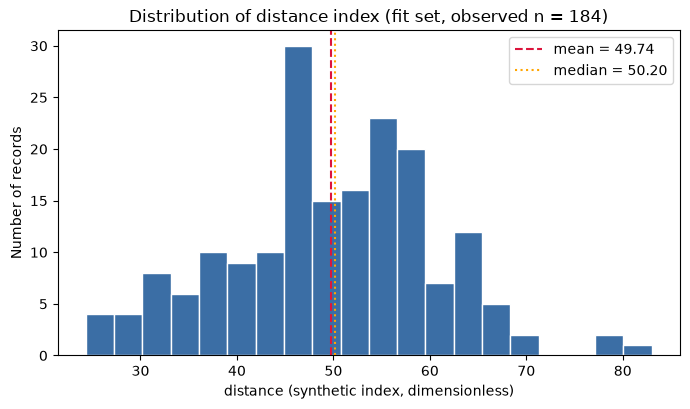

In [ ]:
dist = fit["distance"].dropna()
m1 = {"variable": "distance", "observed_n": int(dist.size), "missing_in_fit": int(fit["distance"].isna().sum()),
      "mean": float(dist.mean()), "median": float(dist.median()), "sample_std_ddof1": float(dist.std(ddof=1))}
pd.DataFrame([m1]).to_csv(OUT / "statistics_summary.csv", index=False)
print(pd.DataFrame([m1]).T.rename(columns={0: "value"}))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(dist, bins=20, color="#3b6ea5", edgecolor="white")
ax.axvline(dist.mean(), color="crimson", ls="--", label=f"mean = {dist.mean():.2f}")
ax.axvline(dist.median(), color="orange", ls=":", label=f"median = {dist.median():.2f}")
ax.set_title(f"Distribution of distance index (fit set, observed n = {dist.size})")
ax.set_xlabel("distance (synthetic index, dimensionless)"); ax.set_ylabel("Number of records")
ax.legend(); fig.tight_layout(); fig.savefig(FIG / "distance_histogram.png", dpi=150); plt.show()

## M2 — Statistical inference
**Welch two-sided t-test** (α = 0.05): is mean `distance` different between operational groups G1 and G2?

* Assumptions: records independent (synthetic i.i.d. draws; no repeated measures after de-duplication) and the
  group means are approximately normal (sample sizes  90 each → CLT; Welch does not require equal variances).
* **95 % t-confidence interval** for the overall observed mean of distance.

In [6]:
g1 = fit.loc[fit.group == "G1", "distance"].dropna()
g2 = fit.loc[fit.group == "G2", "distance"].dropna()
welch = stats.ttest_ind(g1, g2, equal_var=False, alternative="two-sided")
alpha = 0.05

n_, xbar, s = dist.size, dist.mean(), dist.std(ddof=1)
se = s / np.sqrt(n_); tcrit = stats.t.ppf(0.975, n_ - 1)
ci = (xbar - tcrit * se, xbar + tcrit * se)
shapiro = stats.shapiro(dist)

m2 = {"H0": "mean distance G1 == mean distance G2", "H1": "mean distance G1 != mean distance G2",
      "alpha": alpha, "n_G1_observed": int(g1.size), "n_G2_observed": int(g2.size),
      "mean_G1": float(g1.mean()), "mean_G2": float(g2.mean()),
      "welch_t_statistic": float(welch.statistic), "welch_df": float(welch.df), "p_value": float(welch.pvalue),
      "decision": "reject H0" if welch.pvalue < alpha else "fail to reject H0",
      "overall_n": int(n_), "overall_mean": float(xbar), "overall_se": float(se),
      "ci95_lower": float(ci[0]), "ci95_upper": float(ci[1]),
      "shapiro_W_distance": float(shapiro.statistic), "shapiro_p_distance": float(shapiro.pvalue)}
json.dump(m2, open(OUT / "inference_results.json", "w"), indent=2)
print(json.dumps(m2, indent=2))

print("\nINTERPRETATION")
print(f"* Welch test: n(G1)={g1.size}, n(G2)={g2.size}; t={welch.statistic:.3f}, df={welch.df:.1f}, p={welch.pvalue:.4f}. "
      + ("p < 0.05 -> reject H0: " if welch.pvalue < alpha else "p >= 0.05 -> fail to reject H0: ")
      + ("the sample means differ more than chance alone would typically produce." if welch.pvalue < alpha
         else "the data give no clear evidence that mean distance differs between G1 and G2 (this is not proof they are equal)."))
print(f"* 95% CI for the overall mean distance (n={n_}): [{ci[0]:.2f}, {ci[1]:.2f}]. If the sampling were repeated many times, "
      "about 95% of intervals built this way would contain the true mean; it is not a 95% probability statement about this one interval.")
print("* Descriptive/associational only: group membership is not shown to *cause* any difference. "
      f"Shapiro-Wilk p={shapiro.pvalue:.3f} supports (or at least does not contradict) approximate normality.")

{
  "H0": "mean distance G1 == mean distance G2",
  "H1": "mean distance G1 != mean distance G2",
  "alpha": 0.05,
  "n_G1_observed": 104,
  "n_G2_observed": 80,
  "mean_G1": 50.24048076923077,
  "mean_G2": 49.0995,
  "welch_t_statistic": 0.7061612423464614,
  "welch_df": 169.24630441397628,
  "p_value": 0.48105881393425987,
  "decision": "fail to reject H0",
  "overall_n": 184,
  "overall_mean": 49.74440217391305,
  "overall_se": 0.7988311009024627,
  "ci95_lower": 48.16829889365394,
  "ci95_upper": 51.320505454172164,
  "shapiro_W_distance": 0.9885264459622218,
  "shapiro_p_distance": 0.1433298201571686
}

INTERPRETATION
* Welch test: n(G1)=104, n(G2)=80; t=0.706, df=169.2, p=0.4811. p >= 0.05 -> fail to reject H0: the data give no clear evidence that mean distance differs between G1 and G2 (this is not proof they are equal).
* 95% CI for the overall mean distance (n=184): [48.17, 51.32]. If the sampling were repeated many times, about 95% of intervals built this way would contain th

## M3 — Linear algebra (covariance matrix & eigenvalues)
Fit rows **complete** for `distance` and `traffic`; 
eigenvalues from the symmetric routine `np.linalg.eigh`.

In [7]:
X = fit[["distance", "traffic"]].dropna().to_numpy()
n3 = X.shape[0]
Xc = X - X.mean(axis=0)                          # manual centring
cov = Xc.T @ Xc / (n3 - 1)                       # sample covariance
assert np.allclose(cov, np.cov(X, rowvar=False))  # cross-check only
eigvals, eigvecs = np.linalg.eigh(cov)           # ascending order, symmetric-matrix routine
share = eigvals.max() / eigvals.sum()
pc1 = eigvecs[:, np.argmax(eigvals)]

m3 = {"complete_rows_n": int(n3), "covariance_matrix": cov.tolist(),
      "eigenvalues_ascending": eigvals.tolist(), "largest_eigenvalue": float(eigvals.max()),
      "sum_of_eigenvalues": float(eigvals.sum()), "largest_over_sum": float(share),
      "pc1_direction_distance_traffic": pc1.tolist()}
json.dump(m3, open(OUT / "matrix_results.json", "w"), indent=2)
print("n (complete rows) =", n3)
print("Covariance matrix:\n", np.round(cov, 3))
print("Eigenvalues:", np.round(eigvals, 3), "| sum =", round(eigvals.sum(), 3), "| trace =", round(np.trace(cov), 3))
print(f"Largest eigenvalue / sum = {share:.4f}")
print("PC1 direction (distance, traffic):", np.round(pc1, 3))
print(f"\nINTERPRETATION: the first principal direction (unit vector {np.round(pc1,3)}) is the axis of greatest spread of the "
      f"centred (distance, traffic) cloud and carries {share:.1%} of the total variance (= trace). "
      f"{'A share near 50% means the two variables are almost uncorrelated, so no single direction dominates.' if share < 0.6 else 'A larger share indicates the two variables move together.'} "
      "Eigenvector sign is arbitrary.")

n (complete rows) = 184
Covariance matrix:
 [[117.416  -1.236]
 [ -1.236 107.434]]
Eigenvalues: [107.283 117.567] | sum = 224.85 | trace = 224.85
Largest eigenvalue / sum = 0.5229
PC1 direction (distance, traffic): [-0.993  0.121]

INTERPRETATION: the first principal direction (unit vector [-0.993  0.121]) is the axis of greatest spread of the centred (distance, traffic) cloud and carries 52.3% of the total variance (= trace). A share near 50% means the two variables are almost uncorrelated, so no single direction dominates. Eigenvector sign is arbitrary.


---
# Section 2 — Preprocessing & Feature Engineering (F1, F2, F3)
**F1** (audit, partition, disjointness) was executed above — see `outputs/data_audit.json` and `outputs/splits.csv`.

## F2 — Fitted transforms
Everything is **fitted on the 192 fit records only** and then re-used unchanged on validation and test:
1. median imputation of `distance, load, traffic, staff`;
2. `engineered_feature = load / (staff + 1)` on imputed, original-scale values (target never used);
3. `StandardScaler` on the 4 numeric predictors + `engineered_feature`;
4. one-hot encoding of `group` with `handle_unknown="ignore"` — one-hot columns stay **unscaled**.

Code lives in `src/preprocessing.py` (`Preprocessor`).

In [8]:
prep = Preprocessor().fit(fit)                      # learns medians, scaler stats, categories from FIT only
X_fit, X_val, X_test = prep.transform(fit), prep.transform(val), prep.transform(test)
y_fit, y_val, y_test = fit["late"].to_numpy(), val["late"].to_numpy(), test["late"].to_numpy()

print("Learned medians (fit):", dict(zip(NUMERIC, np.round(prep.imputer_.statistics_, 3))))
print("Scaler means:", dict(zip(SCALED_COLS, np.round(prep.scaler_.mean_, 3))))
print("Scaler stds :", dict(zip(SCALED_COLS, np.round(prep.scaler_.scale_, 3))))
print("Categories  :", prep.encoder_.categories_[0].tolist())

# sanity check of the engineered feature on original scale
chk = prep.impute_engineer(fit)
assert np.allclose(chk[ENGINEERED], chk["load"] / (chk["staff"] + 1))
# unseen-category handling demo (does not touch fitted state)
demo = fit.head(2).copy(); demo["group"] = ["G3", "G1"]
print("\nUnseen category 'G3' encodes to all-zero one-hot:\n", prep.transform(demo).filter(like="group_"))

Learned medians (fit): {'distance': np.float64(50.2), 'load': np.float64(49.965), 'traffic': np.float64(49.635), 'staff': np.float64(50.265)}
Scaler means: {'distance': np.float64(49.763), 'load': np.float64(50.25), 'traffic': np.float64(49.305), 'staff': np.float64(50.226), 'engineered_feature': np.float64(1.017)}
Scaler stds : {'distance': np.float64(10.579), 'load': np.float64(10.378), 'traffic': np.float64(10.427), 'staff': np.float64(9.217), 'engineered_feature': np.float64(0.3)}
Categories  : ['G1', 'G2']

Unseen category 'G3' encodes to all-zero one-hot:
      group_G1  group_G2
288       0.0       0.0
73        1.0       0.0


## F3 — Leakage evidence

In [9]:
print("Transformed shapes -> fit:", X_fit.shape, "| validation:", X_val.shape, "| test:", X_test.shape)
print("Feature names:", prep.feature_names_)
finite = {n: bool(np.isfinite(x.to_numpy()).all()) for n, x in [("fit", X_fit), ("val", X_val), ("test", X_test)]}
print("All values finite:", finite); assert all(finite.values())
print("Fit numeric means ≈ 0:", np.round(X_fit[SCALED_COLS].mean().to_numpy(), 6))
print("Fit numeric stds  ≈ 1:", np.round(X_fit[SCALED_COLS].std(ddof=0).to_numpy(), 6))
print("Test numeric means (NOT exactly 0 -> proves test stats were not used):", np.round(X_test[SCALED_COLS].mean().to_numpy(), 3))
assert "late" not in X_fit.columns and "record_id" not in X_fit.columns

prep_audit = {"feature_names": prep.feature_names_, "shapes": {"fit": list(X_fit.shape), "validation": list(X_val.shape), "test": list(X_test.shape)},
              "all_finite": finite, "imputer_medians_from_fit": dict(zip(NUMERIC, map(float, prep.imputer_.statistics_))),
              "scaler_mean_from_fit": dict(zip(SCALED_COLS, map(float, prep.scaler_.mean_))),
              "scaler_scale_from_fit": dict(zip(SCALED_COLS, map(float, prep.scaler_.scale_))),
              "one_hot_categories": prep.encoder_.categories_[0].tolist(), "handle_unknown": "ignore",
              "excluded_from_models": ["late (target)", "record_id (identifier)"]}
json.dump(prep_audit, open(OUT / "preprocessing_audit.json", "w"), indent=2)
joblib.dump(prep, MOD / "preprocessor.joblib")

Transformed shapes -> fit: (192, 7) | validation: (48, 7) | test: (60, 7)
Feature names: ['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']
All values finite: {'fit': True, 'val': True, 'test': True}
Fit numeric means ≈ 0: [ 0. -0. -0. -0.  0.]
Fit numeric stds  ≈ 1: [1. 1. 1. 1. 1.]
Test numeric means (NOT exactly 0 -> proves test stats were not used): [-0.308 -0.008  0.022  0.128 -0.078]


['models\\preprocessor.joblib']

**Why these exclusions prevent leakage**
* **Target (`late`)** is what we want to predict; using it (directly or inside a feature) would let the model "see the answer", giving unrealistic scores that vanish at prediction time.
* **`record_id`** is an arbitrary row label: it carries no delivery information, and could encode generation order, so models would learn noise or an artefact.
* **Test statistics** (means, medians, scaler stds, categories): if the imputer/scaler saw test rows, information from the holdout would leak into training and the test score would be optimistic. Hence all transforms are `fit` on the 192 fit rows and only `transform` the other partitions.
* The validation set is used **only** for ANN early stopping; the test set is evaluated once per final model.
* Fitted preprocessor saved to `models/preprocessor.joblib`; `src/preprocessing.py` recreates it from the fit IDs in `outputs/splits.csv`.

---
# Section 3 — Supervised Learning (S1, S2, S3)
**Target:** `late` (1 = late). **Predictors (7):** `distance, load, traffic, staff, engineered_feature, group_G1, group_G2`.
**Models:** majority-class `DummyClassifier` baseline and `LogisticRegression(max_iter=1000, random_state=42)`, both fitted on the same 192 fit rows.
**Threshold:** 0.5. **Undefined precision/recall** (no predicted/actual positives) are reported as **0** via `zero_division=0`.

## S1 — Baseline and classifier

In [10]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_fit, y_fit)
logreg = LogisticRegression(max_iter=1000, random_state=SEED).fit(X_fit, y_fit)
joblib.dump(dummy, MOD / "baseline_dummy.joblib"); joblib.dump(logreg, MOD / "logistic_regression.joblib")

settings = {"target": "late", "predictors": prep.feature_names_,
            "baseline": "DummyClassifier(strategy='most_frequent')", "classifier": "LogisticRegression(max_iter=1000, random_state=42), default L2 C=1.0, lbfgs",
            "threshold": 0.5, "undefined_precision_recall": "reported as 0 (zero_division=0)",
            "fit_ids": "outputs/splits.csv partition=='fit' (n=192)", "test_ids": "outputs/splits.csv partition=='test' (n=60)"}
json.dump(settings, open(OUT / "supervised_settings.json", "w"), indent=2)
print(json.dumps(settings, indent=2))
print("Baseline predicts class:", dummy.classes_[np.argmax(dummy.class_prior_)])
print(pd.Series(logreg.coef_[0], index=prep.feature_names_).round(3).rename("LR coefficient (standardised features)"))

{
  "target": "late",
  "predictors": [
    "distance",
    "load",
    "traffic",
    "staff",
    "engineered_feature",
    "group_G1",
    "group_G2"
  ],
  "baseline": "DummyClassifier(strategy='most_frequent')",
  "classifier": "LogisticRegression(max_iter=1000, random_state=42), default L2 C=1.0, lbfgs",
  "threshold": 0.5,
  "undefined_precision_recall": "reported as 0 (zero_division=0)",
  "fit_ids": "outputs/splits.csv partition=='fit' (n=192)",
  "test_ids": "outputs/splits.csv partition=='test' (n=60)"
}
Baseline predicts class: 0
distance              1.174
load                  0.525
traffic               1.855
staff                -0.558
engineered_feature    0.946
group_G1             -0.416
group_G2              0.439
Name: LR coefficient (standardised features), dtype: float64


## S2 — Holdout evaluation (untouched 60 test records)

              model  n_test  accuracy  precision  recall     f1
  baseline_majority      60    0.5167     0.0000  0.0000 0.0000
logistic_regression      60    0.8500     0.8846  0.7931 0.8364


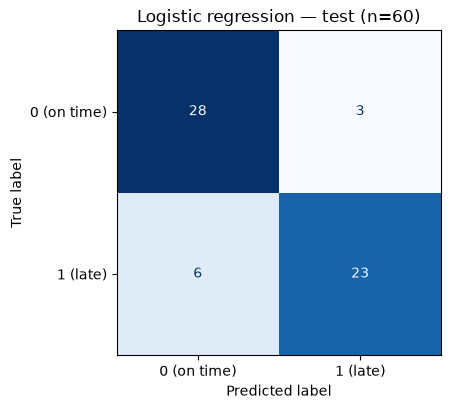

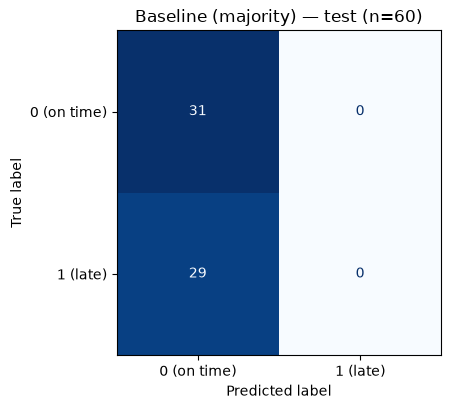

Logistic regression: TN=28 FP=3 FN=6 TP=23


In [11]:
def metric_row(name, y_true, y_pred):
    return {"model": name, "n_test": len(y_true), "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0)}

THRESH = 0.5
lr_proba = logreg.predict_proba(X_test)[:, 1]
lr_pred = (lr_proba >= THRESH).astype(int)
base_pred = dummy.predict(X_test)

metrics = pd.DataFrame([metric_row("baseline_majority", y_test, base_pred), metric_row("logistic_regression", y_test, lr_pred)])
print(metrics.round(4).to_string(index=False))

pred_lr = pd.DataFrame({"record_id": test.record_id.to_numpy(), "true_label": y_test, "predicted_label": lr_pred,
                        "class1_probability": lr_proba, "baseline_predicted_label": base_pred})
pred_lr.to_csv(OUT / "predictions_logistic.csv", index=False)

def save_cm(y_true, y_pred, title, stem):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    pd.DataFrame(cm, index=["true_0_on_time", "true_1_late"], columns=["pred_0_on_time", "pred_1_late"]).to_csv(OUT / f"confusion_matrix_{stem}.csv")
    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    ConfusionMatrixDisplay(cm, display_labels=["0 (on time)", "1 (late)"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title); ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    fig.tight_layout(); fig.savefig(FIG / f"confusion_matrix_{stem}.png", dpi=150); plt.show()
    return cm

cm_lr = save_cm(y_test, lr_pred, "Logistic regression — test (n=60)", "logistic")
cm_base = save_cm(y_test, base_pred, "Baseline (majority) — test (n=60)", "baseline")
tn, fp, fn, tp = cm_lr.ravel(); print(f"Logistic regression: TN={tn} FP={fp} FN={fn} TP={tp}")

## S3 — Interpretation

In [12]:
b, l = metrics.iloc[0], metrics.iloc[1]
print(f"Baseline: acc={b.accuracy:.3f}, F1={b.f1:.3f} | Logistic: acc={l.accuracy:.3f}, prec={l.precision:.3f}, rec={l.recall:.3f}, F1={l.f1:.3f}")
print(f"Accuracy gain over baseline: {l.accuracy - b.accuracy:+.3f}; F1 gain: {l.f1 - b.f1:+.3f}")
print(f"One test record = {1/len(y_test):.3f} accuracy; with n=60 a few records can change results (see CI below).")
lo, hi = stats.binomtest(int(round(l.accuracy * 60)), 60).proportion_ci(0.95, method="wilson")
print(f"Wilson 95% CI for logistic accuracy: [{lo:.3f}, {hi:.3f}]")

Baseline: acc=0.517, F1=0.000 | Logistic: acc=0.850, prec=0.885, rec=0.793, F1=0.836
Accuracy gain over baseline: +0.333; F1 gain: +0.836
One test record = 0.017 accuracy; with n=60 a few records can change results (see CI below).
Wilson 95% CI for logistic accuracy: [0.739, 0.919]


**False positive vs false negative (late-delivery scenario).**
* **False positive** = we flag a shipment as *late* but it would have arrived on time → wasted effort: unnecessary expediting, extra staff, or needless customer warnings that cost money and may erode trust.
* **False negative** = we predict *on time* but the delivery is late → the real problem is missed: no mitigation, an unhappy customer, possible penalties. In most delivery operations this is the more costly error, so **recall** for class 1 deserves weight (the threshold could be lowered — via validation data, never the test set).

**Is the classifier useful?** Yes, relative to the baseline. The majority baseline (always "on time") has accuracy 0.517 on the test set and finds **no** late deliveries (precision, recall and F1 for class 1 are 0 — undefined precision is reported as 0). Logistic regression reaches accuracy 0.850 (+0.333), precision 0.885, recall 0.793 and F1 0.836; it catches 23 of 29 late deliveries (6 false negatives) with 3 false positives. Because recall is below precision, a slightly lower threshold chosen on *validation* data could be explored if misses are costlier. Caveats: the holdout has only 60 records (Wilson 95 % CI for accuracy ≈ 0.74–0.92), one split, synthetic data — so this shows a useful improvement over a trivial rule, **not** deployment readiness.

---
# Section 4 — Unsupervised Learning (U1, U2)
Features: the **5 scaled numeric fit predictors** (`distance, load, traffic, staff, engineered_feature`).
Excluded: `group` one-hot columns, the target and the ID. Only fit data are used (no test data, no labels).

## U1 — K-Means for k = 2, 3, 4 (`n_init=10`, `random_state=42`)

c:\Users\Meet Anghan\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Meet Anghan\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Meet Anghan\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Meet Anghan\AppData\Loc

 k  inertia  silhouette  selected
 2 719.6321      0.2463      True
 3 599.6594      0.2071     False
 4 535.3835      0.1902     False
Selected k = 2


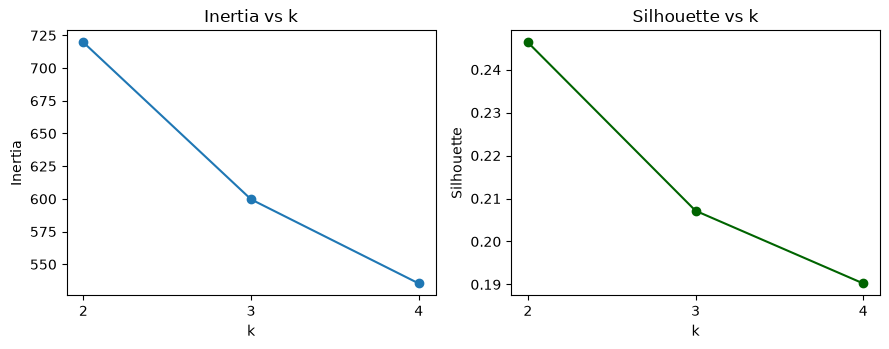

In [13]:
Xc_fit = X_fit[SCALED_COLS].to_numpy()
rows, models_k = [], {}
for k in (2, 3, 4):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Xc_fit)
    models_k[k] = km
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": silhouette_score(Xc_fit, km.labels_)})
ksel = pd.DataFrame(rows)
best_k = int(max(rows, key=lambda r: (round(r["silhouette"], 12), -r["k"]))["k"])   # highest silhouette; ties -> smaller k
ksel["selected"] = ksel.k == best_k
ksel.to_csv(OUT / "k_selection_scores.csv", index=False)
print(ksel.round(4).to_string(index=False)); print("Selected k =", best_k)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ax[0].plot(ksel.k, ksel.inertia, "o-"); ax[0].set_title("Inertia vs k"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia"); ax[0].set_xticks([2,3,4])
ax[1].plot(ksel.k, ksel.silhouette, "o-", color="darkgreen"); ax[1].set_title("Silhouette vs k"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette"); ax[1].set_xticks([2,3,4])
fig.tight_layout(); fig.savefig(FIG / "k_selection.png", dpi=150); plt.show()

**Choice of k.** The rule is *highest silhouette score; ties → smaller k*. Inertia always decreases as k grows, so it cannot be used alone
to choose k; silhouette measures both cohesion and separation. A silhouette below ≈ 0.25–0.30 means clusters are weak, overlapping groupings
of a continuous cloud rather than natural, well-separated groups (see the printed value).

## U2 — Segment interpretation

                                0       1
cluster                     0.000   1.000
size                      134.000  58.000
distance_mean              48.419  52.869
load_mean                  47.128  57.462
traffic_mean               49.066  49.856
staff_mean                 54.035  41.427
engineered_feature_mean     0.863   1.373
distance_zmean             -0.127   0.294
load_zmean                 -0.301   0.695
traffic_zmean              -0.023   0.053
staff_zmean                 0.413  -0.955
engineered_feature_zmean   -0.514   1.187
share_of_fit                0.698   0.302


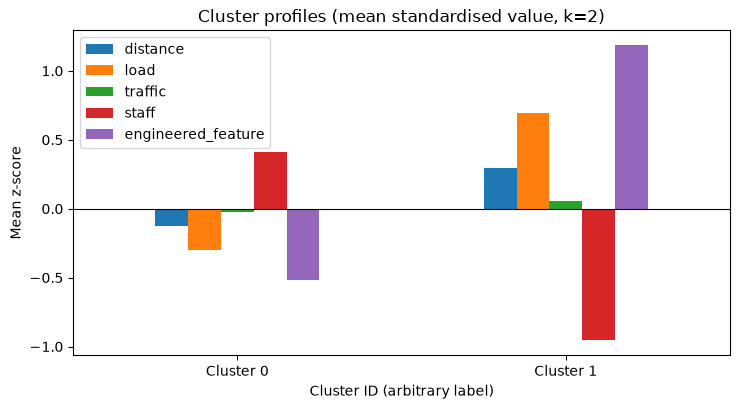

In [14]:
km = models_k[best_k]
unscaled = prep.impute_engineer(fit)[SCALED_COLS].copy()          # original-scale, imputed (fit only)
unscaled["cluster"] = km.labels_
zs = pd.DataFrame(Xc_fit, columns=SCALED_COLS); zs["cluster"] = km.labels_

prof_raw = unscaled.groupby("cluster").mean().add_suffix("_mean")
prof_z = zs.groupby("cluster").mean().add_suffix("_zmean")
prof = pd.concat([unscaled.groupby("cluster").size().rename("size"), prof_raw, prof_z], axis=1).reset_index()
prof["share_of_fit"] = prof["size"] / len(fit)
prof.to_csv(OUT / "cluster_profiles.csv", index=False)
print(prof.round(3).T.to_string())

fig, ax = plt.subplots(figsize=(7.5, 4.2))
prof_z.set_index(prof_z.index.map(lambda c: f"Cluster {c}")).rename(columns=lambda c: c.replace("_zmean", "")).plot.bar(ax=ax)
ax.axhline(0, color="k", lw=0.8); ax.set_title(f"Cluster profiles (mean standardised value, k={best_k})")
ax.set_xlabel("Cluster ID (arbitrary label)"); ax.set_ylabel("Mean z-score"); plt.xticks(rotation=0)
fig.tight_layout(); fig.savefig(FIG / "cluster_profiles.png", dpi=150); plt.show()

**Result (k = 2, silhouette = 0.246 — the highest of the three; k = 3 → 0.207, k = 4 → 0.190).** The silhouette is low, so the two segments are *soft, overlapping* groups rather than sharply separated clusters; treat them as a convenient operational lens, not natural categories.

| Cluster ID | Size (share of fit) | Profile (mean z-scores; original-scale means in `cluster_profiles.csv`) | Descriptive name | One practical action |
|---|---|---|---|---|
| **0** | 134 (69.8 %) | staff **+0.41**, load **−0.30**, engineered_feature **−0.51**, distance −0.13, traffic ≈ 0 | **"Well-staffed, lighter-load routes"** | Keep current staffing; treat as a pool from which spare capacity can be borrowed during peaks. |
| **1** | 58 (30.2 %) | staff **−0.96**, load **+0.70**, engineered_feature **+1.19**, distance +0.29, traffic ≈ 0 | **"Understaffed, high-load routes"** | Add or reassign staff (or cap load per staff member) on these deliveries and monitor them first for delay risk. |

**Cluster IDs are arbitrary.** K-Means numbers clusters by the order of random initial centroids; re-running with another seed could swap "0" and "1" without changing the grouping. IDs carry no order and are **not** the target classes (`late` = 0/1): clustering never saw the target, so a cluster is a *similarity* group in feature space, not a prediction of lateness. No test data and no labels were used to fit or choose the clusters.

---
# Section 5 — Deep Learning up to ANN (D1, D2, D3)

## D1 — Architecture & compilation
Dense feed-forward network: **Input(7) → Dense(16, ReLU) → Dense(8, ReLU) → Dense(1, sigmoid)**.
* Input width = number of transformed features (7).
* **Sigmoid output** squashes the logit into (0, 1) = estimated P(late = 1); it fits a *binary* target.
* **Binary cross-entropy** is the negative log-likelihood of a Bernoulli outcome; it penalises confident wrong probabilities and pairs naturally with sigmoid.
* Optimiser: **Adam**, learning rate **0.001**.

In [15]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
n_features = X_fit.shape[1]
ann = keras.Sequential([
    keras.layers.Input(shape=(n_features,)),
    keras.layers.Dense(16, activation="relu", name="hidden_16"),
    keras.layers.Dense(8, activation="relu", name="hidden_8"),
    keras.layers.Dense(1, activation="sigmoid", name="output"),
], name="late_delivery_ann")
ann.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
ann.summary()
trainable = int(sum(np.prod(w.shape) for w in ann.trainable_weights))
print("Trainable parameters:", trainable, "(= 7*16+16 + 16*8+8 + 8*1+1 = 128 + 136 + 9)")
assert trainable == 273

Model: "late_delivery_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_16 (Dense)               │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_8 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 273 (= 7*16+16 + 16*8+8 + 8*1+1 = 128 + 136 + 9)


## D2 — Training & validation
Train on the 192 fit rows, batch size 16, ≤ 50 epochs; validation = the reserved 48 rows; `EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)`. Seed = 42.

Seed: 42 | epochs actually run: 40 (max 50) | best epoch (restored weights): 35
Best val_loss=0.4357 | final-epoch train_loss=0.3298, val_loss=0.4360
 epoch  accuracy   loss  val_accuracy  val_loss
    33    0.8490 0.3498          0.75    0.4369
    34    0.8438 0.3459          0.75    0.4358
    35    0.8438 0.3425          0.75    0.4357
    36    0.8438 0.3394          0.75    0.4359
    37    0.8438 0.3365          0.75    0.4358
    38    0.8490 0.3339          0.75    0.4358
    39    0.8438 0.3317          0.75    0.4358
    40    0.8438 0.3298          0.75    0.4360


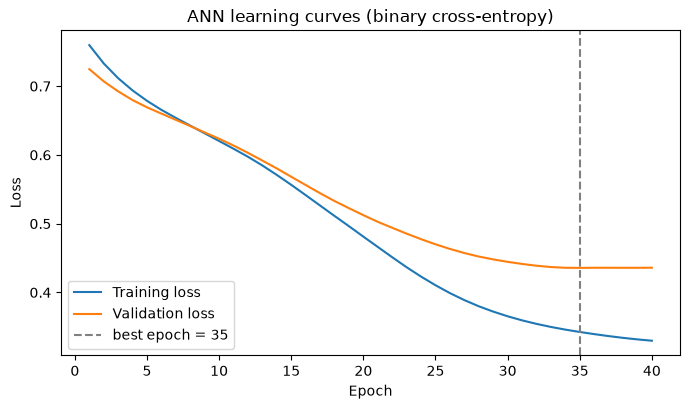

In [16]:
early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
hist = ann.fit(X_fit.to_numpy("float32"), y_fit, validation_data=(X_val.to_numpy("float32"), y_val),
               epochs=50, batch_size=16, callbacks=[early], shuffle=True, verbose=0)
H = pd.DataFrame(hist.history); H.index.name = "epoch_index"; H.insert(0, "epoch", np.arange(1, len(H) + 1))
H.to_csv(OUT / "ann_training_history.csv", index=False)
epochs_run = len(H); best_epoch = int(H["val_loss"].idxmin()) + 1
print(f"Seed: {SEED} | epochs actually run: {epochs_run} (max 50) | best epoch (restored weights): {best_epoch}")
print(f"Best val_loss={H.val_loss.min():.4f} | final-epoch train_loss={H.loss.iloc[-1]:.4f}, val_loss={H.val_loss.iloc[-1]:.4f}")
print(H.round(4).tail(8).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(H.epoch, H.loss, label="Training loss"); ax.plot(H.epoch, H.val_loss, label="Validation loss")
ax.axvline(best_epoch, color="gray", ls="--", label=f"best epoch = {best_epoch}")
ax.set_title("ANN learning curves (binary cross-entropy)"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "ann_loss_curves.png", dpi=150); plt.show()

**Underfitting / overfitting discussion.**
* *Early epochs:* both losses start high (~0.76 train / 0.72 validation, accuracy ≈ 0.5, i.e. chance) — a small network with learning rate 0.001 needs many epochs to start learning; this is slow learning, not final underfitting.
* *Middle epochs:* training and validation loss fall together (validation ≈ 0.44 at the best epoch), so the model is learning real signal.
* *Late epochs:* training loss keeps falling (≈ 0.33) while validation loss flattens at ≈ 0.436 and stops improving after epoch 35; early stopping (patience 5) halted at epoch 40 and restored the epoch-35 weights. The train–validation gap of ≈ 0.1 is a **mild** generalisation gap — the beginning of overfitting — but there is **no sharp rise** in validation loss, so overfitting is not severe.
* *Caveat:* the validation set has only 48 rows, so the validation curve is noisy and its accuracy moves in steps of ≈ 0.02.

## D3 — Comparison & evidence
The restored (best-epoch) ANN is evaluated **once** on the same 60 test records at threshold 0.5.

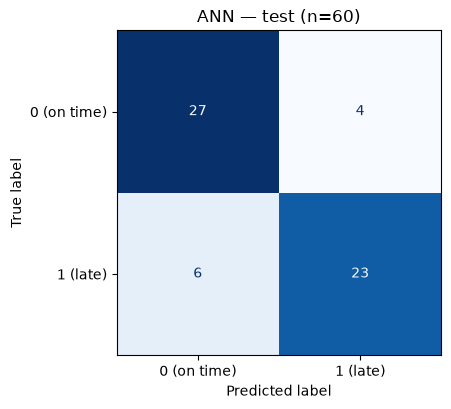

              model  n_test  accuracy  precision  recall     f1  fit_n  threshold
  baseline_majority      60    0.5167     0.0000  0.0000 0.0000    192        0.5
logistic_regression      60    0.8500     0.8846  0.7931 0.8364    192        0.5
                ann      60    0.8333     0.8519  0.7931 0.8214    192        0.5

ANN confusion matrix [[TN FP],[FN TP]]:
 [[27  4]
 [ 6 23]]
F1 difference (ANN - logistic) = -0.0149


In [17]:
ann_proba = ann.predict(X_test.to_numpy("float32"), verbose=0).ravel()
ann_pred = (ann_proba >= THRESH).astype(int)
pred_ann = pd.DataFrame({"record_id": test.record_id.to_numpy(), "true_label": y_test, "predicted_label": ann_pred, "class1_probability": ann_proba})
pred_ann.to_csv(MOD / "ann_predictions.csv", index=False); pred_ann.to_csv(OUT / "predictions_ann.csv", index=False)
cm_ann = save_cm(y_test, ann_pred, "ANN — test (n=60)", "ann")

ann.save(MOD / "ann_model.keras"); ann.save_weights(MOD / "ann.weights.h5")

metrics_all = pd.concat([metrics, pd.DataFrame([metric_row("ann", y_test, ann_pred)])], ignore_index=True)
metrics_all["fit_n"] = 192; metrics_all["threshold"] = THRESH
metrics_all.to_csv(OUT / "model_metrics_comparison.csv", index=False)
print(metrics_all.round(4).to_string(index=False))
print("\nANN confusion matrix [[TN FP],[FN TP]]:\n", cm_ann)
print(f"F1 difference (ANN - logistic) = {metrics_all.f1.iloc[2] - metrics_all.f1.iloc[1]:+.4f}")

**Comparison and model preference.** On the same 60 test records: logistic regression — accuracy 0.850, precision 0.885, recall 0.793, **F1 0.836**; ANN — accuracy 0.833, precision 0.852, recall 0.793, **F1 0.821** (ANN − LR = −0.015). The two models have the *same recall* (23 of 29 late deliveries found); the ANN makes one more false positive (4 vs 3). One record out of 60 is the whole difference, which is well inside the noise of a single small holdout — this is **not** evidence that either model is truly better.

**Preference: logistic regression.** With equal recall and a marginally higher F1/precision, it is also far simpler (8 parameters vs 273), trains instantly, needs no early-stopping/seed management, and its coefficients are directly interpretable (e.g. higher `traffic` and `distance` raise the late-odds; higher `staff` lowers them). The ANN adds complexity without a measurable benefit for 7 tabular features and 192 training rows. Both beat the majority baseline (accuracy 0.517, F1 0).

---
# Section 6 — Reconciliation, reload test & evidence
Test metrics are recomputed from the **saved prediction files**, test IDs are verified identical for both models,
and the saved ANN + preprocessor are reloaded from disk to prove the hand-off works.

In [18]:
p_lr, p_ann = pd.read_csv(OUT / "predictions_logistic.csv"), pd.read_csv(MOD / "ann_predictions.csv")
assert list(p_lr.record_id) == list(p_ann.record_id), "models must use identical test IDs in identical order"
assert set(p_lr.record_id) == ids["test"] and len(p_lr) == 60
for name, p, row in [("logistic_regression", p_lr, 1), ("ann", p_ann, 2)]:
    m = metric_row(name, p.true_label.to_numpy(), p.predicted_label.to_numpy())
    for k in ("accuracy", "precision", "recall", "f1"):
        assert abs(m[k] - metrics_all.loc[row, k]) < 1e-12, (name, k)
print("Reconciliation OK: metrics recomputed from saved predictions match the comparison table; test IDs identical for both models.")

# --- reload test: load saved preprocessor + ANN from disk and re-predict the test set
prep2 = joblib.load(MOD / "preprocessor.joblib"); ann2 = keras.models.load_model(MOD / "ann_model.keras")
proba2 = ann2.predict(prep2.transform(test).to_numpy("float32"), verbose=0).ravel()
assert np.allclose(proba2, p_ann.class1_probability.to_numpy(), atol=1e-6)
print("Reload test OK: saved ANN + preprocessor reproduce the saved test probabilities.")

print("\nFiles written:")
for p in sorted(list(OUT.glob("*")) + list(FIG.glob("*")) + list(MOD.glob("*"))):
    if p.is_file(): print(" ", p.as_posix())

Reconciliation OK: metrics recomputed from saved predictions match the comparison table; test IDs identical for both models.
Reload test OK: saved ANN + preprocessor reproduce the saved test probabilities.

Files written:
  models/ann.weights.h5
  models/ann_model.keras
  models/ann_predictions.csv
  models/baseline_dummy.joblib
  models/logistic_regression.joblib
  models/preprocessor.joblib
  outputs/ann_training_history.csv
  outputs/cluster_profiles.csv
  outputs/confusion_matrix_ann.csv
  outputs/confusion_matrix_baseline.csv
  outputs/confusion_matrix_logistic.csv
  outputs/data_audit.json
  outputs/figures/ann_loss_curves.png
  outputs/figures/cluster_profiles.png
  outputs/figures/confusion_matrix_ann.png
  outputs/figures/confusion_matrix_baseline.png
  outputs/figures/confusion_matrix_logistic.png
  outputs/figures/distance_histogram.png
  outputs/figures/k_selection.png
  outputs/inference_results.json
  outputs/k_selection_scores.csv
  outputs/matrix_results.json
  outputs/

### How to load the saved models later
```python
import joblib, pandas as pd
from tensorflow import keras
from src.preprocessing import Preprocessor          # needed to unpickle the preprocessor
prep = joblib.load("models/preprocessor.joblib")
ann  = keras.models.load_model("models/ann_model.keras")
p_late = ann.predict(prep.transform(new_df).to_numpy("float32"))   # new_df needs columns distance, load, traffic, staff, group
```

### Limitations
Synthetic data; n = 300 (60-record holdout); single random split; no causal claims; not deployment-ready; no test-set tuning and no seed selection was performed (seed fixed at 42).